In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, aberration, equatorial2galactic, galactic2equatorial
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import leastsq
import h5py
import platophot as phot

In [2]:
sim = Simulation("StellarVariability")
switchOffAllEffects(sim)
numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures
workDir = os.environ["PLATO_WORKDIR"]
sim.outputDir = workDir

position = 4000
dim = 100
numSubPixels = sim["SubField/SubPixels"]

sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Variability

magnitude = 12.5
starCatalogFilename = workDir + "generatedFromPixelCoordinates.starcat"
sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([magnitude]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

variabilityFilename = workDir + "variability.txt"

cycleTime = sim["ObservingParameters/CycleTime"]
period = 20 * cycleTime
time = np.arange(3000.)
sin = np.sin(2 * math.pi / period * time)

myFile = open(variabilityFilename, "w")
for n in range(len(time)):
    myFile.write("{0}  {1}\n".format(time[n], sin[n]))
myFile.close()

varsourceFilename = workDir + "varsource.txt"

myFile = open(varsourceFilename, "w")
myFile.write("{0}  {1}\n".format(1, variabilityFilename))
myFile.close()

sim["Sky/VariableSourceList"] = varsourceFilename
sim["Sky/IncludeVariableSources"] = "yes"

sim["SubField/ZeroPointRow"] = position - dim // 2
sim["SubField/ZeroPointColumn"] = position - dim // 2
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

sim["FEE/Gain/RefValueLeft"] = 1.0
sim["FEE/Gain/RefValueRight"] = 1.0
sim["CCD/Gain/RefValueLeft"] = 1.0
sim["CCD/Gain/RefValueRight"] = 1.0
# sim["CCD/IncludeQuantisation"] = "yes"

output = sim.run(removeOutputFile = True)

(0, 100)

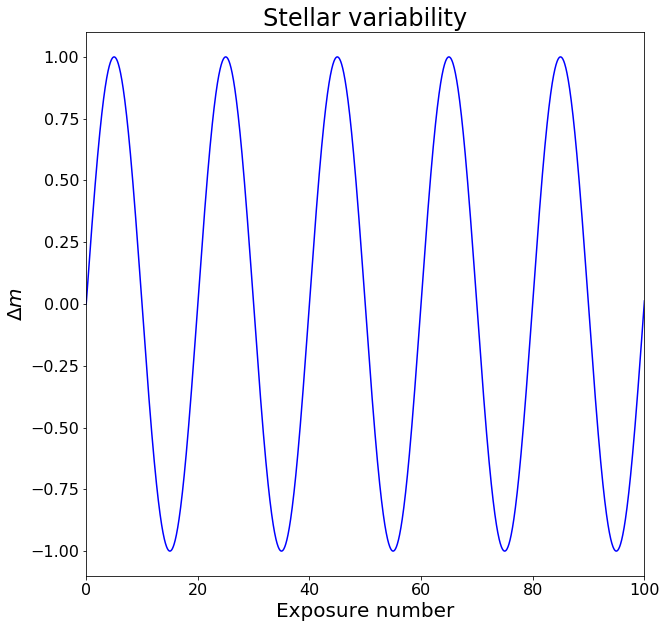

In [3]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)

plt.plot(time / cycleTime, sin, "b")
plt.title("Input $\Delta$ m", fontsize=24)
plt.xlabel("Exposure number", fontsize=20)
plt.ylabel("$\Delta m$", fontsize=20)

plt.title("Stellar variability", fontsize = 24)
# plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0, 100])

In [4]:
inputMagnitudes = sin + magnitude

In [5]:
exposureTime = cycleTime - sim.getReadoutTime()[0]

fluxes = np.array([])

for exposure in range(sim["ObservingParameters/NumExposures"]):
    
    ID, rows, columns, Xmm, Ymm, flux = output.getStarCoordinates(exposure)
    fluxes = np.append(fluxes, flux)     # [photons]

outputMagnitudes = -2.5 * np.log10(fluxes / (exposureTime * sim["ObservingParameters/Fluxm0"] * sim["Camera/ThroughputBandwidth"] * sim["Telescope/LightCollectingArea"] * sim["Telescope/TransmissionEfficiency/BOL"] * 1E-4))

(11.0, 14.0)

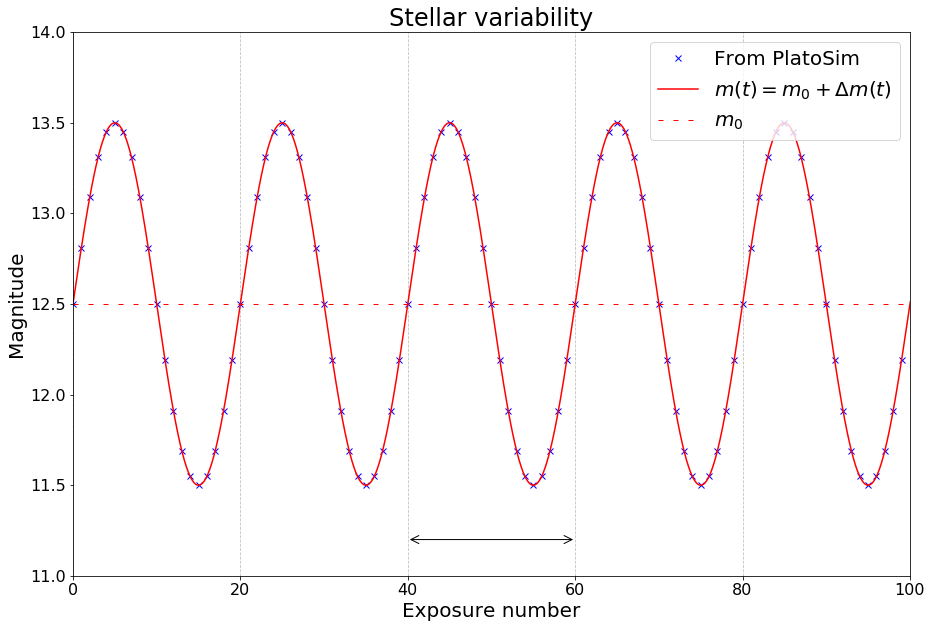

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(outputMagnitudes, "bx", label="From PlatoSim")



########
# Theory
########

exposureTime = cycleTime - sim.getReadoutTime()[0]
plt.plot(time / cycleTime, inputMagnitudes, "r", label="$m(t) = m_0 + \Delta m(t)}$" )
plt.axhline(y = magnitude, color = "r", linestyle=(0, (5, 10)), linewidth=1, label = "$m_0$")

plt.grid(color = "gray", axis="x", linestyle="--", alpha=0.5)



########
# Layout
########

plt.annotate(s='', xy=(40, 11.2), xytext=(60, 11.2), arrowprops=dict(arrowstyle='<->'), fontsize=20)

plt.title("Stellar variability", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Magnitude", fontsize = 20)
plt.xlim([0, 100])
plt.ylim([magnitude - 1.5, magnitude + 1.5])

In [7]:
time2 = np.arange(100)
data = outputMagnitudes

optimize_func = lambda x: x[0] * np.sin(2 * math.pi / x[1] * time2) + x[2] - data
estAmpl, estPeriod, estBaseline = leastsq(optimize_func, [1.0, period / cycleTime, 12.5])[0]

# recreate the fitted curve using the optimized parameters
# data_fit = est_amp*np.sin(2 * math.pi / est_period * time) + est_mean

print("Fitted amplitude: ", estAmpl)
print("Fitted period: ", estPeriod)
print("Fitted baseline: ", estBaseline)

Fitted amplitude:  1.0000057003212857
Fitted period:  20.00000000640176
Fitted baseline:  12.500007478404067


In [8]:
starIDsInImage0, row, col, Xmm, Ymm, flux = output.getStarCoordinates(0)
print("Start")
phot.photometry(workDir + "StellarVariability.hdf5", "photometryOutput.hdf5", starIDsInImage0, maxNexposures=numExposures)
print("Done")

Start
0 100
Looping over all images in HDF5 file.
Image # 0
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 1.0

In [9]:
photFile = h5py.File("photometryOutput.hdf5")
estimatedFluxes = np.array([])

for exposure in range(numExposures):
    
    groupName = "Photometry/Exposure{0:06d}/estimatedFlux".format(exposure)
    estimatedFlux    = np.array(photFile[groupName])

    estimatedFluxes = np.append(estimatedFluxes, estimatedFlux)

# print("Before: ", estimatedFluxes)
# estimatedFluxes *= (sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"])
# print("After: ", estimatedFluxes)
outputMagnitudes = -2.5 * np.log10(estimatedFluxes / (exposureTime * sim["ObservingParameters/Fluxm0"] * sim["Camera/ThroughputBandwidth"] * sim["Telescope/LightCollectingArea"] * sim["Telescope/TransmissionEfficiency/BOL"] * 1E-4))

(11.0, 14.0)

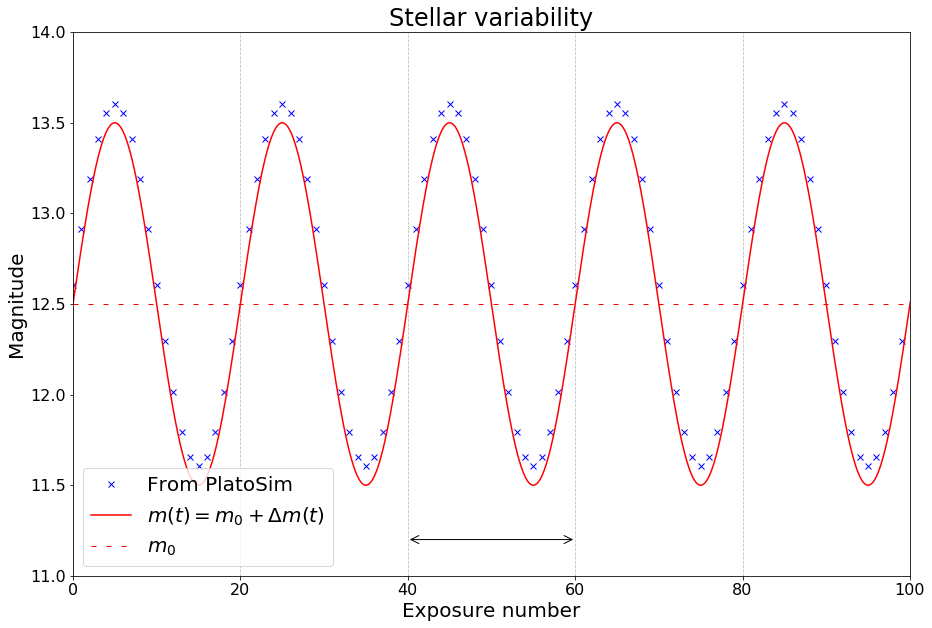

In [10]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(outputMagnitudes, "bx", label="From PlatoSim")


# ########
# # Theory
# ########

exposureTime = cycleTime - sim.getReadoutTime()[0]
plt.plot(time / cycleTime, inputMagnitudes, "r", label="$m(t) = m_0 + \Delta m(t)}$" )
plt.axhline(y = magnitude, color = "r", linestyle=(0, (5, 10)), linewidth=1, label = "$m_0$")

plt.grid(color = "gray", axis="x", linestyle="--", alpha=0.5)



########
# Layout
########

plt.annotate(s='', xy=(40, 11.2), xytext=(60, 11.2), arrowprops=dict(arrowstyle='<->'), fontsize=20)

plt.title("Stellar variability", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Magnitude", fontsize = 20)
plt.xlim([0, 100])
plt.ylim([magnitude - 1.5, magnitude + 1.5])

In [11]:
np.mean(outputMagnitudes)

12.60410439189515

In [12]:
np.max(outputMagnitudes) - np.min(outputMagnitudes)

2.0000228490537566

In [13]:
output.getImage(0)

array([[5835., 5835., 5835., ..., 5835., 5835., 5835.],
       [5835., 5835., 5835., ..., 5835., 5835., 5835.],
       [5835., 5835., 5835., ..., 5835., 5835., 5835.],
       ...,
       [5835., 5835., 5835., ..., 5835., 5835., 5835.],
       [5835., 5835., 5835., ..., 5835., 5835., 5835.],
       [5835., 5835., 5835., ..., 5835., 5835., 5835.]], dtype=float32)

In [14]:
time2 = np.arange(100)
data = outputMagnitudes

optimize_func = lambda x: x[0] * np.sin(2 * math.pi / x[1] * time2) + x[2] - data
estAmpl, estPeriod, estBaseline = leastsq(optimize_func, [1.0, period / cycleTime, 12.5])[0]

# recreate the fitted curve using the optimized parameters
# data_fit = est_amp*np.sin(2 * math.pi / est_period * time) + est_mean

print("Fitted amplitude: ", estAmpl)
print("Fitted period: ", estPeriod)
print("Fitted baseline: ", estBaseline)

Fitted amplitude:  1.0000056888964735
Fitted period:  20.00000000699953
Fitted baseline:  12.60410439184041
